## Import Libraries

In [ ]:
!pip install qiskit

!pip install qiskit-aer

!pip install tdqr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.4 MB/s eta 0:00:00


In [2]:
import numpy as np
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
import qiskit.circuit.classical as qiskit_classical
from qiskit.quantum_info import SparsePauliOp
from IPython.display import display
#from qiskit.opflow import I, Z, StateFn, PauliExpectation, CircuitSampler
#from qiskit import Aer, execute, transpile
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

## AER Pure SWAPNET

### Set SWAPNET

In [10]:
class ising_class:
    def __init__(self, d, steps, t, J, h):
        self.d = d
        self.steps = steps
        self.t = t
        self.J = J
        self.h = h

    def get_trotterized_ising_circuit(self):
        
        """
        Returns a QuantumCircuit implementing a trotterized Ising evolution for d qubits.

        H = - J * sum(Z_i Z_{i+1}) - h * sum(X_i)
        U = exp(-i H t) 
        """
        t = self.t
        steps = self.steps
        d = self.d
        J = self.J
        h = self.h

        dt = t / steps
        qc = QuantumCircuit(d)

        for _ in range(steps):
            # Apply ZZ interactions (Z_i Z_{i+1})
            for i in range(d - 1):
                qc.cx(i, i + 1)
                qc.rz(-2 * J * dt, i + 1)
                qc.cx(i, i + 1)

            # Apply transverse field X terms (X_i)
            for i in range(d):
                qc.rx(-2 * h * dt, i)

        return qc

    def apply_ising_to_registers(self, qc,start):
        """
        Apply trotterized Ising circuit to registers q1, q2, q3 in a 4d-sized register circuit.
        """
        d = self.d
        ising = self.get_trotterized_ising_circuit()

        # Convert to instruction and append to registers q1, q2, q3
        ising_inst = ising.to_instruction()
        for reg in [1, 2, 3]:
            qc.append(ising_inst, [(reg-1) * d + i + start for i in range(d)])

        return qc

    def get_trotterized_ising_statevector(self):
        """
        Returns the statevector from the trotterized Ising evolution of d qubits.
        """
        qc = self.get_trotterized_ising_circuit()
        qc.save_statevector()

        simulator = AerSimulator()
        result = simulator.run(transpile(qc, simulator)).result()
        return result.get_statevector()


def get_QPA_circuit(d, N, ising_circuit,single_control=False,reduced_if=False):
    #FUNCTION TO GET QPA CIRCUIT
    if single_control:
       ncontrols=1
       get_control = lambda x: 0
    else:
       ncontrols=d
       get_control = lambda x: x
    cr_q0 = ClassicalRegister(ncontrols,name='control')
    qr_all = QuantumRegister(3*d+ncontrols)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP,start=ncontrols) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for k in range(ncontrols):
        qc.reset(k)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for k in range(ncontrols-1):
        qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(get_control(k), k+ncontrols, k+d+ncontrols)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for k in range(ncontrols):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1




      for i in range(ncontrols): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+d+ncontrols, k+2*d+ncontrols) #Swap q2 with q3
        if not reduced_if:
          if N!=1:
            qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
            
      if reduced_if:
         if N!=1:
          qc = recursive(N-1,qc)
      return qc
    
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc

def get_QPA_circuit_d_controls(d, N, ising_circuit):
    #FUNCTION TO GET QPA CIRCUIT

    cr_q0 = ClassicalRegister(d,name='control')
    qr_all = QuantumRegister(4*d)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP,start=d) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for k in range(d):
        qc.reset(k)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for k in range(d-1):
        qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(0+k, k+d, k+2*d)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for k in range(d):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1




      for i in range(d): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+2*d, k+3*d) #Swap q2 with q3
        if N!=1:
          qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc



def get_QPA_circuit_single_control(d, N, ising_circuit):
    #FUNCTION TO GET QPA CIRCUIT

    cr_q0 = ClassicalRegister(1,name='control')
    qr_all = QuantumRegister(3*d+1)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP,start=1) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      qc.reset(0)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(0, k+1, k+d+1)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      qc.h(0)
      # Measure qubits 0 to d-1 into classical bits 0 to d-1



      qc.measure(0,cr_q0[0])
      for i in range(d): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+2*d, k+3*d) #Swap q2 with q3
        if N!=1:
          qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc

def run_qc_and_return_state(qc):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state

def estimate_qc_and_return_distribution(qc,observables,estimator = AerEstimator()):
    #RUN THE CIRCUIT AND MEASURE CLASSICALLY THE STATE IN REGISTER Q3, SHOULD RETURN A SEQUENCE OF BITS OF d DIMENSIONS FOR EACH SHOT, REPRESENTING THE FINAL STATE MEASURED
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    isa_circuit = pass_manager.run(qc)
    qc_transpiled = transpile(isa_circuit)

    result = estimator.run([(qc_transpiled,observables,None)]).result()
    exp_val = result[0].data.evs
    print(result[0].data.stds)
    return exp_val
    # pub_result = result[0]
    # counts = pub_result.data.control.get_counts()
    # return counts





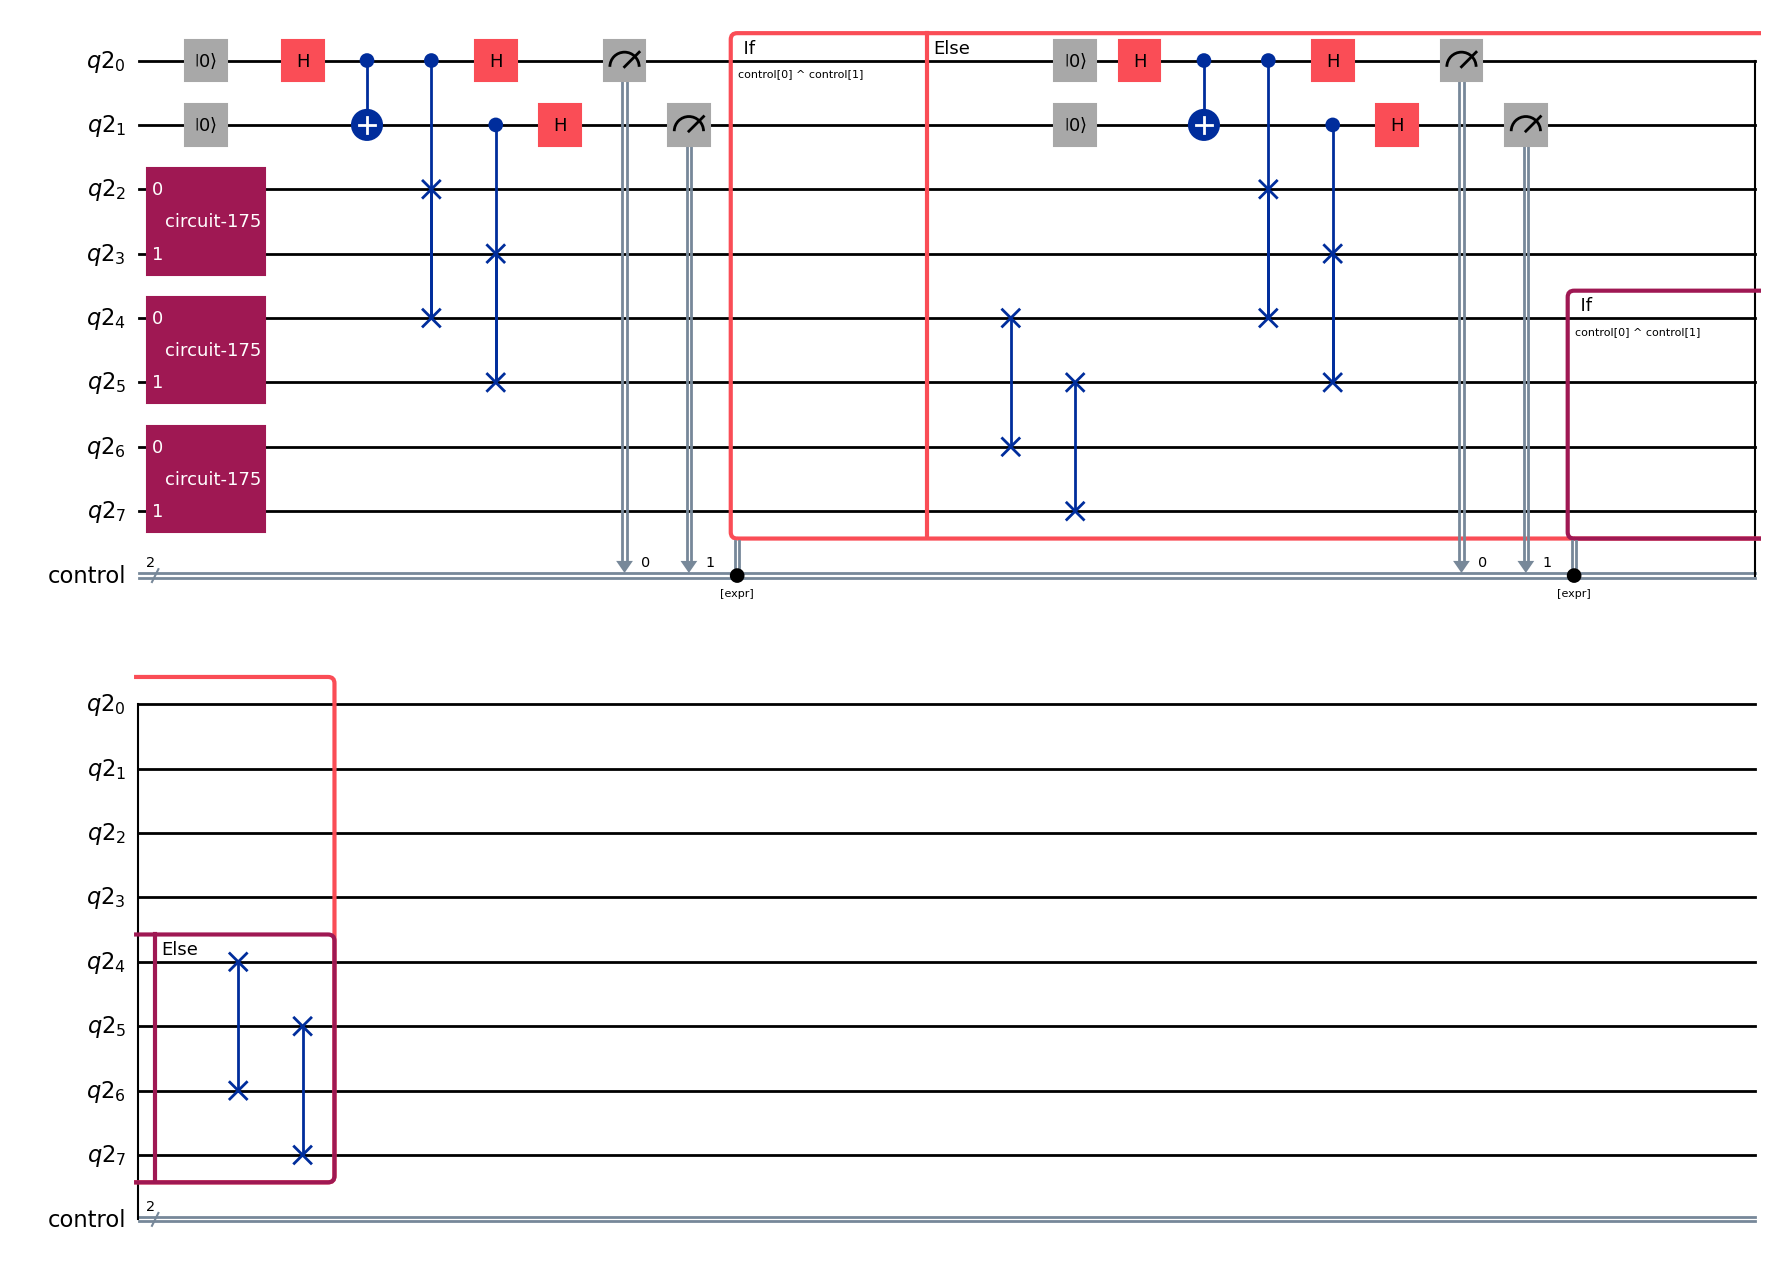

In [5]:
t=5.0
J=1
h=1
steps = 5
d=2

ising = ising_class(d, steps, t, J, h)
epsilon = 1.0
N_qpa = 2
QPA_multiple = get_QPA_circuit(d, N_qpa, ising, single_control=False, reduced_if=False)
QPA_multiple.draw('mpl')



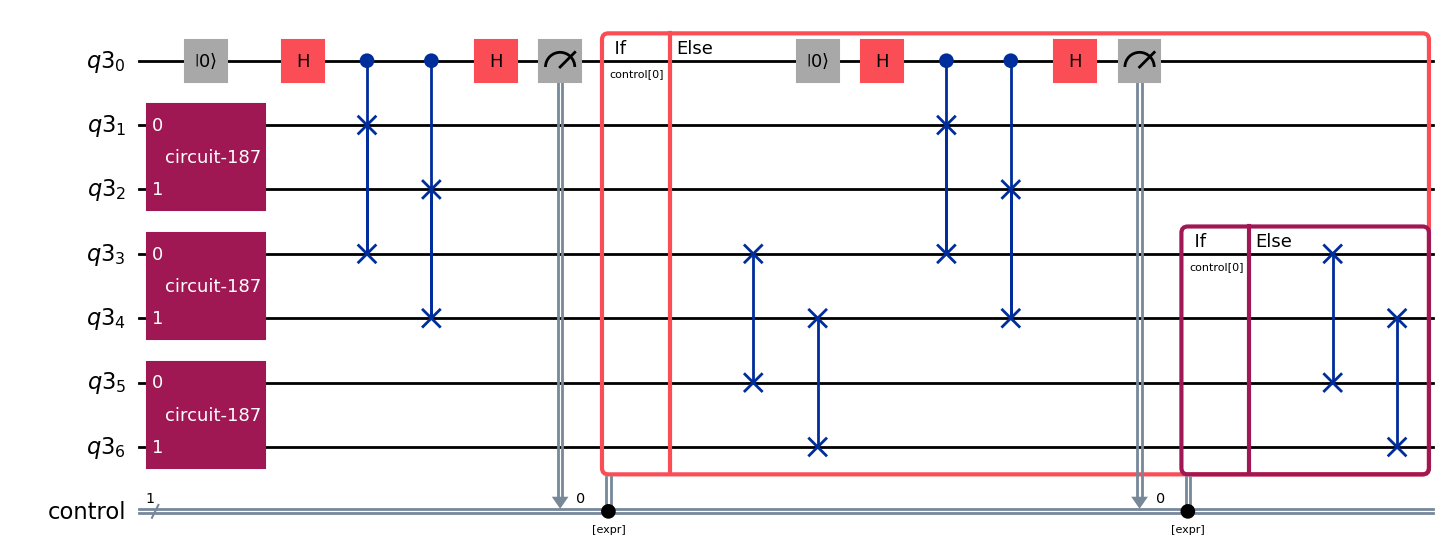

In [6]:
t=5.0
J=1
h=1
steps = 5
d=2

ising = ising_class(d, steps, t, J, h)
epsilon = 1.0
N_qpa = 2
QPA_single = get_QPA_circuit(d, N_qpa, ising, single_control=True, reduced_if=False)
QPA_single.draw('mpl')


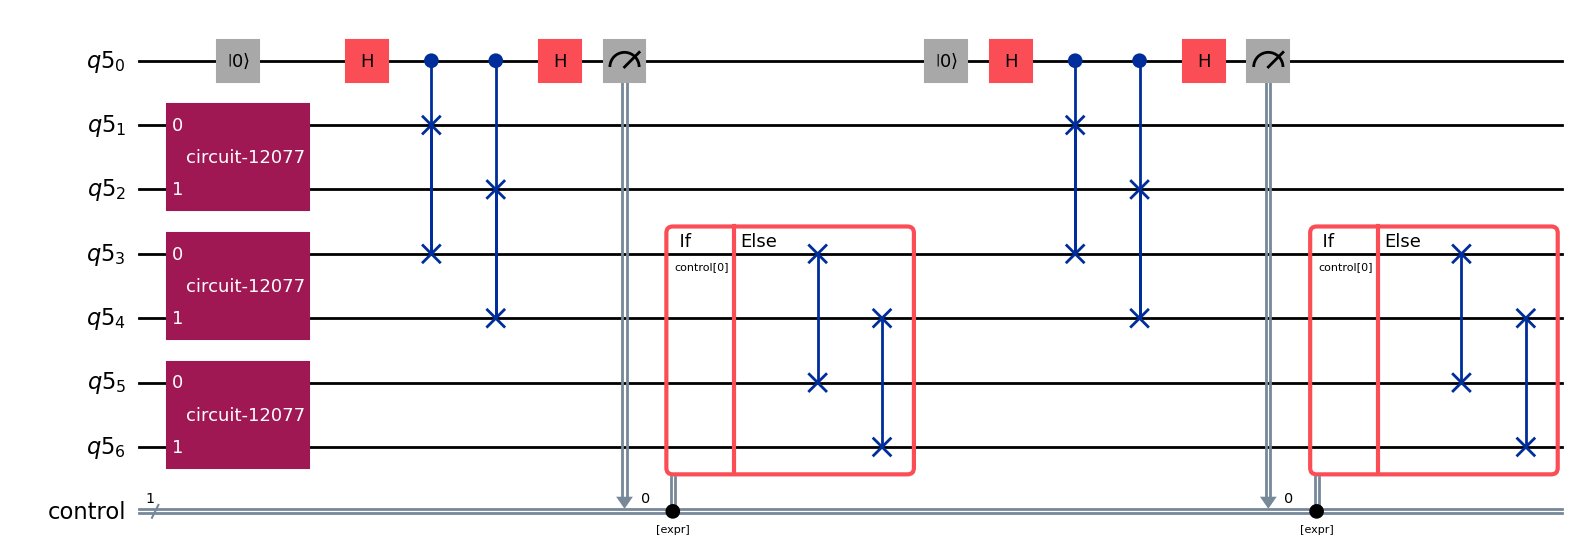

In [9]:
t=5.0
J=1
h=1
steps = 5
d=2

ising = ising_class(d, steps, t, J, h)
epsilon = 1.0
N_qpa = 2
QPA_single_reduced = get_QPA_circuit(d, N_qpa, ising, single_control=True, reduced_if=True)
QPA_single_reduced.draw('mpl')


In [ ]:

# Run the function
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.005, 1), ['h', 'x','rx','rz'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.005, 2), ['cx'])
t=5.0
J=1
h=1
steps = 5
d=3

ising = ising_class(d, steps, t, J, h)
epsilon = 1.0
N_qpa = 2
QPA = get_QPA_circuit(d, N_qpa, ising)
estimator = AerEstimator(options=dict(backend_options=dict(noise_model=noise_model, shots=1024*10)))


trotterized_state = ising.get_trotterized_ising_statevector()
display(trotterized_state.draw('latex'))
#CALCULATE THE PROJECTION OPERATOR FOR THE Q3 REGISTER -------------------
# Assuming trotterized_state is your Statevector for the q3 register
projector_q3 = SparsePauliOp.from_operator(trotterized_state.to_operator())


# Create an identity operator for the other registers
identity_op = SparsePauliOp(["I" * (d)])

# Tensor the identity with the projector
full_projector = projector_q3.tensor(identity_op).tensor(identity_op).tensor(identity_op)
# full_projector = identity_op.tensor(identity_op).tensor(identity_op).tensor(projector_q3)

print(estimate_qc_and_return_distribution(QPA,[full_projector],estimator=estimator))


# TESTING THE ESTIMATOR ------------------------------------------------
state = trotterized_state  # type: Statevector

rho = state.to_operator()  # This is |psi><psi| as a matrix

projector_pauli = SparsePauliOp.from_operator(rho)

qc_ising = ising.get_trotterized_ising_circuit()
# print(transpile(qc_ising).draw())
print(estimate_qc_and_return_distribution(qc_ising,[projector_pauli],estimator=estimator))



# # psi_purified = run_qc_and_return_state(QPA)
# #print(transpile(QPA).draw())
# # display(psi_purified.draw('latex'))


<IPython.core.display.Latex object>

[0.]
[0.81612235]
[0.]
[0.79455215]


## RUN ESTIMATOR

In [14]:

t=5.0
J=1
h=1
steps = 5
d=3
ising = ising_class(d, steps, t, J, h)
trotterized_state = ising.get_trotterized_ising_statevector()
display(trotterized_state.draw('latex'))


def get_projector(single_control= False):
    fidelity_operator = SparsePauliOp.from_operator(trotterized_state.to_operator())
    identity_op = SparsePauliOp(["I" * (d)])
    if single_control:
        control_identity = SparsePauliOp(["I"])
    else:
        control_identity = identity_op
    full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(control_identity)
    return full_space_fidelity_operator


<IPython.core.display.Latex object>

Lambda Loop: 100%|██████████| 10/10 [01:01<00:00,  6.12s/it]

{0: [array(1.), array(0.96919925), array(0.9394958), array(0.91085057), array(0.88322585), array(0.85658525), array(0.83089368), array(0.80611729), array(0.78222343), array(0.75918061)], 1: [array(1.), array(0.9771118), array(0.95231627), array(0.92548923), array(0.90782463), array(0.873624), array(0.85223779), array(0.83532925), array(0.81085397), array(0.79153844)], 2: [array(1.), array(0.9779297), array(0.95480377), array(0.92556629), array(0.90635355), array(0.87817969), array(0.84949809), array(0.82160863), array(0.795059), array(0.77451627)]}


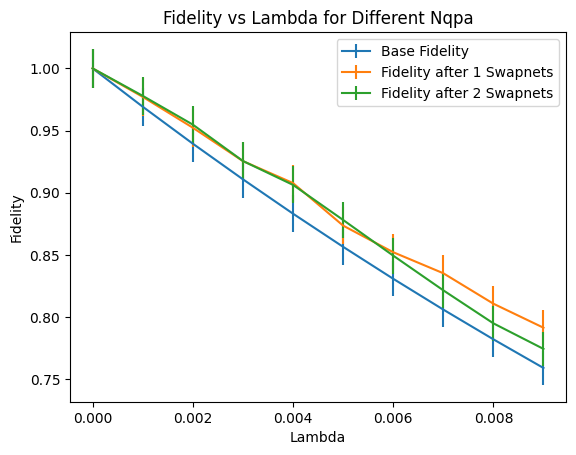

In [15]:
#DO THE PLOTTING -------------------------
import numpy as np
import matplotlib.pyplot as plt
import time  # Import time module for tracking execution time
from tqdm import tqdm
list_of_noise = [i * 0.001 for i in range(10)]
list_of_Nqpa = [0,1,2]
purified_fidelity = {i: [] for i in list_of_Nqpa}
theorical_fidelity=[]

shots = 1024*4
debug = False # Set to False to disable print statements



pass_manager = generate_preset_pass_manager(3, AerSimulator())


for noise in tqdm(list_of_noise, desc="Lambda Loop"):
    # Theoretical max fidelity
    # LAMBDA = ising.get_trotterized_ising_circuit
    # if d==2:#1/8 (-2 + \[Lambda]) (1 + \[Lambda]) (-4 + 3 \[Lambda])
    #     theorical_fidelity.append(1/8 * (-2 + LAMBDA) * (1 + LAMBDA) * (-4 + 3*LAMBDA))
    # elif d==3: #1/96 (-8 + 7 \[Lambda]) (-12 + 7 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/96 * (-8 + 7*LAMBDA) * (-12 + 7*(-1 + LAMBDA)*LAMBDA))
    # elif d==4:#1/128 (-16 + 15 \[Lambda]) (-8 + 5 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/128 * (-16 + 15*LAMBDA) * (-8 + 5*(-1 + LAMBDA)*LAMBDA))
    # else:#Just give 0 for now
    #     theorical_fidelity.append(0)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ['h', 'x','rx','rz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ['cx'])
    estimator = AerEstimator(options=dict(backend_options=dict(noise_model=noise_model, shots=shots)))

    for Nqpa in list_of_Nqpa:
        full_space_fidelity_operator = get_projector()
        QPA = get_QPA_circuit(d, Nqpa, ising)
        isa_circuit = pass_manager.run(QPA)
        qc_transpiled = transpile(isa_circuit)
        result = estimator.run([(qc_transpiled,full_space_fidelity_operator,None)]).result()
        fidelity = result[0].data.evs
        purified_fidelity[Nqpa].append(fidelity)


print(purified_fidelity)
# Plot results
for Nqpa in list_of_Nqpa:
    fidelity = np.array(purified_fidelity[Nqpa])
    if Nqpa==0:
        label = 'Base Fidelity'
    else:
        label = f'Fidelity after {Nqpa} Swapnets'
    plt.errorbar(list_of_noise, purified_fidelity[Nqpa],
                 yerr=np.sqrt(fidelity/shots), label=label)

# plt.plot(list_of_lambda, theorical_fidelity, label='Theoretical Maximum Fidelity')

plt.xlabel('Lambda')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Lambda for Different Nqpa')
plt.legend()
plt.show()


Lambda Loop: 100%|██████████| 10/10 [00:52<00:00,  5.24s/it]

{0: [array(1.), array(0.96919925), array(0.9394958), array(0.91085057), array(0.88322585), array(0.85658525), array(0.83089368), array(0.80611729), array(0.78222343), array(0.75918061)], 1: [array(1.), array(0.97538403), array(0.95395126), array(0.9297189), array(0.90557063), array(0.87818332), array(0.85810791), array(0.82446864), array(0.80254002), array(0.78896313)], 2: [array(1.), array(0.97700512), array(0.95341979), array(0.92813235), array(0.90217165), array(0.87636609), array(0.85272345), array(0.83826014), array(0.79575791), array(0.7830808)]}


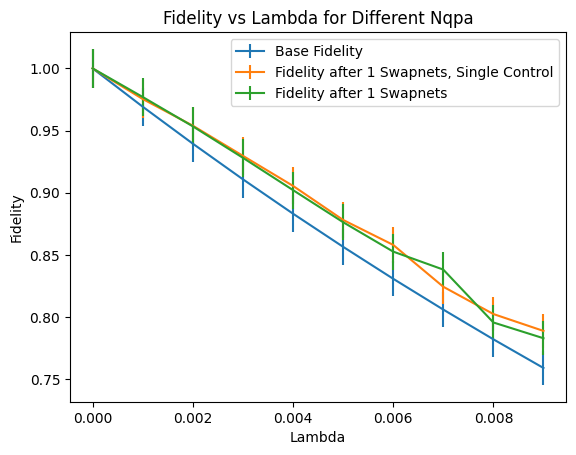

In [ ]:
#DO THE PLOTTING -------------------------
import numpy as np
import matplotlib.pyplot as plt
import time  # Import time module for tracking execution time
from tqdm import tqdm
list_of_noise = [i * 0.001 for i in range(10)]
list_of_qpas = [(0,True,False),(1,True,False),(1,False,False)]
purified_fidelity = {i: [] for i in range(len(list_of_qpas))}
theorical_fidelity=[]

shots = 1024*4
debug = False # Set to False to disable print statements



pass_manager = generate_preset_pass_manager(3, AerSimulator())


for noise in tqdm(list_of_noise, desc="Lambda Loop"):
    # Theoretical max fidelity
    # LAMBDA = ising.get_trotterized_ising_circuit
    # if d==2:#1/8 (-2 + \[Lambda]) (1 + \[Lambda]) (-4 + 3 \[Lambda])
    #     theorical_fidelity.append(1/8 * (-2 + LAMBDA) * (1 + LAMBDA) * (-4 + 3*LAMBDA))
    # elif d==3: #1/96 (-8 + 7 \[Lambda]) (-12 + 7 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/96 * (-8 + 7*LAMBDA) * (-12 + 7*(-1 + LAMBDA)*LAMBDA))
    # elif d==4:#1/128 (-16 + 15 \[Lambda]) (-8 + 5 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/128 * (-16 + 15*LAMBDA) * (-8 + 5*(-1 + LAMBDA)*LAMBDA))
    # else:#Just give 0 for now
    #     theorical_fidelity.append(0)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ['h', 'x','rx','rz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ['cx'])
    estimator = AerEstimator(options=dict(backend_options=dict(noise_model=noise_model, shots=shots)))

    for j,params in enumerate(list_of_qpas):
        Nqpa,single_control,reduced_if = params
        QPA = get_QPA_circuit(d, Nqpa, ising,single_control,reduced_if)
        full_space_fidelity_operator = get_projector(single_control)
        isa_circuit = pass_manager.run(QPA)
        qc_transpiled = transpile(isa_circuit)
        result = estimator.run([(qc_transpiled,full_space_fidelity_operator,None)]).result()
        fidelity = result[0].data.evs
        purified_fidelity[j].append(fidelity)


print(purified_fidelity)
# Plot results
for j,params in enumerate(list_of_qpas):
    Nqpa,single_control,reduced_if = params
    fidelity = np.array(purified_fidelity[j])
    if Nqpa==0:
        label = 'Base Fidelity'
    else:
        label = f'Fidelity after {Nqpa} Swapnets'
        if single_control:
            label += ', Single Control'
        if reduced_if:
            label += ', Reduced if'
    plt.errorbar(list_of_noise, purified_fidelity[j],
                 yerr=np.sqrt(fidelity/shots), label=label)

# plt.plot(list_of_lambda, theorical_fidelity, label='Theoretical Maximum Fidelity')

plt.xlabel('Lambda')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Lambda for Different Nqpa')
plt.legend()
plt.show()


Lambda Loop: 100%|██████████| 10/10 [00:48<00:00,  4.81s/it]

{0: [array(1.), array(0.96919925), array(0.9394958), array(0.91085057), array(0.88322585), array(0.85658525), array(0.83089368), array(0.80611729), array(0.78222343), array(0.75918061)], 1: [array(1.), array(0.97689039), array(0.95608154), array(0.9262716), array(0.9029176), array(0.88111275), array(0.85471624), array(0.82701733), array(0.80651306), array(0.77301849)], 2: [array(1.), array(0.97656799), array(0.95247393), array(0.93079702), array(0.90024155), array(0.86939411), array(0.86141595), array(0.83548288), array(0.80477807), array(0.77920861)]}


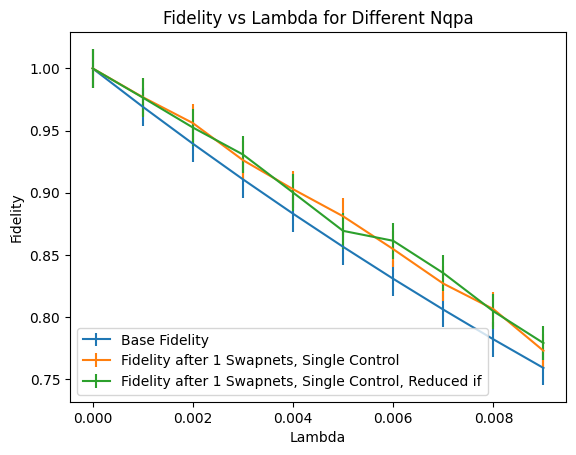

In [19]:
#DO THE PLOTTING -------------------------
import numpy as np
import matplotlib.pyplot as plt
import time  # Import time module for tracking execution time
from tqdm import tqdm
list_of_noise = [i * 0.001 for i in range(10)]
list_of_qpas = [(0,True,False),(1,True,False),(1,True,True)]
purified_fidelity = {i: [] for i in range(len(list_of_qpas))}
theorical_fidelity=[]

shots = 1024*4
debug = False # Set to False to disable print statements



pass_manager = generate_preset_pass_manager(3, AerSimulator())


for noise in tqdm(list_of_noise, desc="Lambda Loop"):
    # Theoretical max fidelity
    # LAMBDA = ising.get_trotterized_ising_circuit
    # if d==2:#1/8 (-2 + \[Lambda]) (1 + \[Lambda]) (-4 + 3 \[Lambda])
    #     theorical_fidelity.append(1/8 * (-2 + LAMBDA) * (1 + LAMBDA) * (-4 + 3*LAMBDA))
    # elif d==3: #1/96 (-8 + 7 \[Lambda]) (-12 + 7 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/96 * (-8 + 7*LAMBDA) * (-12 + 7*(-1 + LAMBDA)*LAMBDA))
    # elif d==4:#1/128 (-16 + 15 \[Lambda]) (-8 + 5 (-1 + \[Lambda]) \[Lambda])
    #     theorical_fidelity.append(1/128 * (-16 + 15*LAMBDA) * (-8 + 5*(-1 + LAMBDA)*LAMBDA))
    # else:#Just give 0 for now
    #     theorical_fidelity.append(0)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ['h', 'x','rx','rz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ['cx'])
    estimator = AerEstimator(options=dict(backend_options=dict(noise_model=noise_model, shots=shots)))

    for j,params in enumerate(list_of_qpas):
        Nqpa,single_control,reduced_if = params
        QPA = get_QPA_circuit(d, Nqpa, ising,single_control,reduced_if)
        full_space_fidelity_operator = get_projector(single_control)
        isa_circuit = pass_manager.run(QPA)
        qc_transpiled = transpile(isa_circuit)
        result = estimator.run([(qc_transpiled,full_space_fidelity_operator,None)]).result()
        fidelity = result[0].data.evs
        purified_fidelity[j].append(fidelity)


print(purified_fidelity)
# Plot results
for j,params in enumerate(list_of_qpas):
    Nqpa,single_control,reduced_if = params
    fidelity = np.array(purified_fidelity[j])
    if Nqpa==0:
        label = 'Base Fidelity'
    else:
        label = f'Fidelity after {Nqpa} Swapnets'
        if single_control:
            label += ', Single Control'
        if reduced_if:
            label += ', Reduced if'
    plt.errorbar(list_of_noise, purified_fidelity[j],
                 yerr=np.sqrt(fidelity/shots), label=label)

# plt.plot(list_of_lambda, theorical_fidelity, label='Theoretical Maximum Fidelity')

plt.xlabel('Lambda')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Lambda for Different Nqpa')
plt.legend()
plt.show()
